# 🔧 Notebook 3: Feature Engineering
## Transforming Raw Metadata into Discriminative Representations

**Objective:** Engineer features that capture clinical domain knowledge and expose hidden 
signals in the TBP metadata. This is the **breakthrough module** — where we transform raw 
measurements into representations that simplify the learning task.

> **Philosophy:** Good features should encode *dermatological reasoning* — the ABCDE criteria 
> (Asymmetry, Border, Color, Diameter, Evolution) that clinicians use to assess lesions.

---

In [1]:
# ============================================================
# Setup
# ============================================================
import os, sys, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from scipy import stats

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (14, 6), 'font.size': 12})
SEED = 42
np.random.seed(SEED)

ROOT = os.getcwd()

DATA_DIR = os.path.join(ROOT, 'ISIC 2024 Skin Cancer Challenge Dataset')
FIG_DIR  = os.path.join(ROOT, 'outputs', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

# Load full training data
df = pd.read_csv(os.path.join(DATA_DIR, 'train-metadata.csv'), low_memory=False)
print(f"✅ Loaded {len(df):,} samples, {df.shape[1]} columns")

✅ Loaded 401,059 samples, 55 columns


## 3.1 Feature Engineering Pipeline

Our feature engineering strategy creates five categories of new features:

| Category | Rationale | Clinical Basis |
|---|---|---|
| **Color Space** | Ratios and interactions between L*a*b* channels | Color variation criterion |
| **Geometric** | Shape indices from area, perimeter, eccentricity | Border irregularity criterion |
| **Delta Features** | Lesion-vs-surrounding-skin differences | Evolution/contrast criterion |
| **Patient-Level Z-Scores** | How unusual a lesion is for its patient | Contextual anomaly detection |
| **Site residuals (Notebook 4)** | Lesion value minus site mean | Computed **per CV fold** from train only (avoids leakage) |

In [2]:
# ============================================================
# 3.1 — The Feature Engineering Function
# ============================================================
def engineer_features(df):
    """
    Comprehensive feature engineering pipeline for ISIC 2024 metadata.

    Creates many new features in categories:
    1. Color space features
    2. Geometric features
    3. Delta (contrast) features
    4. Patient-level z-scores
    5. Cross-feature interactions
    6. Categorical encodings

    Site-vs-mean residuals (anatomical site) are NOT added here — they leak if
    computed on the full table. Notebook 4 adds them per CV fold from train only.

    Parameters
    ----------
    df : pd.DataFrame
        Raw metadata with TBP columns

    Returns
    -------
    pd.DataFrame
        DataFrame with original + engineered features
    """
    out = df.copy()
    n_before = out.shape[1]

    # ── 1. COLOR SPACE FEATURES ──
    out['feat_L_A_ratio'] = out['tbp_lv_L'] / (out['tbp_lv_A'].abs() + 1e-6)
    out['feat_L_B_ratio'] = out['tbp_lv_L'] / (out['tbp_lv_B'].abs() + 1e-6)
    out['feat_A_B_ratio'] = out['tbp_lv_A'] / (out['tbp_lv_B'].abs() + 1e-6)

    out['feat_chroma'] = np.sqrt(out['tbp_lv_A']**2 + out['tbp_lv_B']**2)
    out['feat_chroma_ext'] = np.sqrt(out['tbp_lv_Aext']**2 + out['tbp_lv_Bext']**2)

    out['feat_deltaE'] = np.sqrt(
        out['tbp_lv_deltaL']**2 +
        out['tbp_lv_deltaA']**2 +
        out['tbp_lv_deltaB']**2
    )

    out['feat_L_ratio_lesion_skin'] = out['tbp_lv_L'] / (out['tbp_lv_Lext'] + 1e-6)
    out['feat_A_ratio_lesion_skin'] = out['tbp_lv_A'] / (out['tbp_lv_Aext'].abs() + 1e-6)
    out['feat_B_ratio_lesion_skin'] = out['tbp_lv_B'] / (out['tbp_lv_Bext'].abs() + 1e-6)

    out['feat_color_heterogeneity'] = out['tbp_lv_color_std_mean'] * out['tbp_lv_radial_color_std_max']
    out['feat_stdL_ratio'] = out['tbp_lv_stdL'] / (out['tbp_lv_stdLExt'] + 1e-6)

    # ── 2. GEOMETRIC (SHAPE) FEATURES ──
    out['feat_compactness'] = (4 * np.pi * out['tbp_lv_areaMM2']) / (out['tbp_lv_perimeterMM']**2 + 1e-6)
    out['feat_major_axis'] = out['tbp_lv_areaMM2'] / (out['tbp_lv_minorAxisMM'] + 1e-6)
    out['feat_axis_ratio'] = out['tbp_lv_minorAxisMM'] / (out['feat_major_axis'] + 1e-6)
    out['feat_border_irregularity'] = out['tbp_lv_norm_border'] * (1 - out['tbp_lv_symm_2axis'])
    out['feat_size_shape'] = out['tbp_lv_areaMM2'] * out['tbp_lv_eccentricity']

    expected_area = np.pi * (out['clin_size_long_diam_mm'] / 2) ** 2
    out['feat_area_diameter_ratio'] = out['tbp_lv_areaMM2'] / (expected_area + 1e-6)

    # ── 3. DELTA (LESION vs SKIN) FEATURES ──
    out['feat_deltaL_norm'] = out['tbp_lv_deltaL'] / (out['tbp_lv_L'] + 1e-6)
    out['feat_deltaA_norm'] = out['tbp_lv_deltaA'] / (out['tbp_lv_A'].abs() + 1e-6)
    out['feat_deltaB_norm'] = out['tbp_lv_deltaB'] / (out['tbp_lv_B'].abs() + 1e-6)
    out['feat_delta_magnitude'] = np.sqrt(
        out['tbp_lv_deltaL']**2 +
        out['tbp_lv_deltaA']**2 +
        out['tbp_lv_deltaB']**2
    )
    out['feat_log_deltaLB'] = np.log1p(out['tbp_lv_deltaLB'].abs())

    # ── 4. PATIENT-LEVEL CONTEXT (Z-SCORES) ──
    patient_features = ['tbp_lv_L', 'tbp_lv_A', 'tbp_lv_B', 'tbp_lv_areaMM2',
                        'tbp_lv_eccentricity', 'tbp_lv_color_std_mean',
                        'tbp_lv_nevi_confidence', 'clin_size_long_diam_mm']

    for feat in patient_features:
        patient_stats = out.groupby('patient_id')[feat].agg(['mean', 'std'])
        patient_stats.columns = [f'{feat}_patient_mean', f'{feat}_patient_std']
        out = out.merge(patient_stats, on='patient_id', how='left')
        std_col = f'{feat}_patient_std'
        mean_col = f'{feat}_patient_mean'
        out[f'feat_zscore_{feat.replace("tbp_lv_", "")}'] = (
            (out[feat] - out[mean_col]) / (out[std_col] + 1e-6)
        )
        out.drop([mean_col, std_col], axis=1, inplace=True)

    patient_counts = out.groupby('patient_id')['isic_id'].transform('count')
    out['feat_patient_lesion_count'] = patient_counts
    out['feat_log_patient_lesions'] = np.log1p(patient_counts)

    # ── 5. CROSS-FEATURE INTERACTIONS ──
    out['feat_size_color'] = out['tbp_lv_areaMM2'] * out['tbp_lv_color_std_mean']
    out['feat_age_size'] = out['age_approx'] * out['clin_size_long_diam_mm']
    out['feat_confidence_nevi_diff'] = out['tbp_lv_dnn_lesion_confidence'] - out['tbp_lv_nevi_confidence']
    out['feat_asymm_color'] = (1 - out['tbp_lv_symm_2axis']) * out['tbp_lv_color_std_mean']
    out['feat_border_delta'] = out['tbp_lv_norm_border'] * out['feat_deltaE']

    # ── 6. CATEGORICAL ENCODING ──
    for col in ['sex', 'anatom_site_general', 'tbp_tile_type', 'tbp_lv_location',
                'tbp_lv_location_simple', 'image_type']:
        if col in out.columns:
            out[f'{col}_encoded'] = out[col].astype(str).factorize()[0]

    n_after = out.shape[1]
    print(f"Feature engineering: {n_before} → {n_after} columns (+{n_after - n_before} new features)")

    return out


print("Running feature engineering on full dataset...")
df_feat = engineer_features(df)
print(f"\n✅ Final shape: {df_feat.shape}")

# Grouped split for feature *selection* only (fold 0 train ≈ 80% of patients)
from sklearn.model_selection import StratifiedGroupKFold
_sel_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
SELECTION_TRAIN_IDX, SELECTION_VAL_IDX = next(_sel_cv.split(df_feat, df_feat['target'], df_feat['patient_id']))
print(f"Selection split (AUC/MI only): train rows={len(SELECTION_TRAIN_IDX):,}, "
      f"val rows={len(SELECTION_VAL_IDX):,} (patients do not overlap)")


Running feature engineering on full dataset...
Feature engineering: 55 → 98 columns (+43 new features)

✅ Final shape: (401059, 98)
Selection split (AUC/MI only): train rows=320,848, val rows=80,211 (patients do not overlap)


## 3.2 Feature Impact Analysis

We now verify that our engineered features actually improve discriminative power by comparing 
individual AUC scores before (raw features) vs after (engineered features).

In [3]:
# ============================================================
# 3.2 — Before vs After: Feature AUC Comparison (selection train only)
# ============================================================
def compute_feature_aucs(dataframe, target_col='target'):
    """Compute individual AUC for each numeric feature."""
    aucs = {}
    for col in dataframe.select_dtypes(include=[np.number]).columns:
        if col == target_col:
            continue
        valid = dataframe[[col, target_col]].dropna()
        if len(valid) < 100 or valid[target_col].nunique() < 2:
            continue
        try:
            auc = roc_auc_score(valid[target_col], valid[col])
            aucs[col] = max(auc, 1 - auc)
        except Exception:
            pass
    return pd.Series(aucs).sort_values(ascending=False)

df_sel = df_feat.iloc[SELECTION_TRAIN_IDX]
df_raw_sel = df.iloc[SELECTION_TRAIN_IDX]

original_aucs = compute_feature_aucs(df_raw_sel)
all_aucs = compute_feature_aucs(df_sel)

new_feat_names = [c for c in df_feat.columns if c.startswith('feat_') or c.endswith('_encoded')]
new_aucs = all_aucs[[c for c in new_feat_names if c in all_aucs.index]].sort_values(ascending=False)

print("TOP 15 ENGINEERED FEATURES (univariate AUC, selection train only):")
print("=" * 55)
for feat, auc in new_aucs.head(15).items():
    print(f"  {feat:45s} AUC = {auc:.4f}")

print(f"\n\nTOP 15 ORIGINAL NUMERIC FEATURES (selection train only):")
print("=" * 55)
for feat, auc in original_aucs.head(15).items():
    print(f"  {feat:45s} AUC = {auc:.4f}")


TOP 15 ENGINEERED FEATURES (univariate AUC, selection train only):
  feat_A_B_ratio                                AUC = 0.7970
  feat_B_ratio_lesion_skin                      AUC = 0.7488
  feat_deltaB_norm                              AUC = 0.7488
  feat_zscore_B                                 AUC = 0.7166
  feat_zscore_L                                 AUC = 0.6499
  feat_L_A_ratio                                AUC = 0.6351
  feat_zscore_A                                 AUC = 0.6331
  feat_size_color                               AUC = 0.6317
  feat_zscore_areaMM2                           AUC = 0.6257
  feat_L_B_ratio                                AUC = 0.6224
  feat_zscore_color_std_mean                    AUC = 0.6219
  feat_color_heterogeneity                      AUC = 0.6134
  feat_age_size                                 AUC = 0.6122
  feat_border_delta                             AUC = 0.6105
  feat_zscore_clin_size_long_diam_mm            AUC = 0.6074


TOP 15 ORIGINAL 

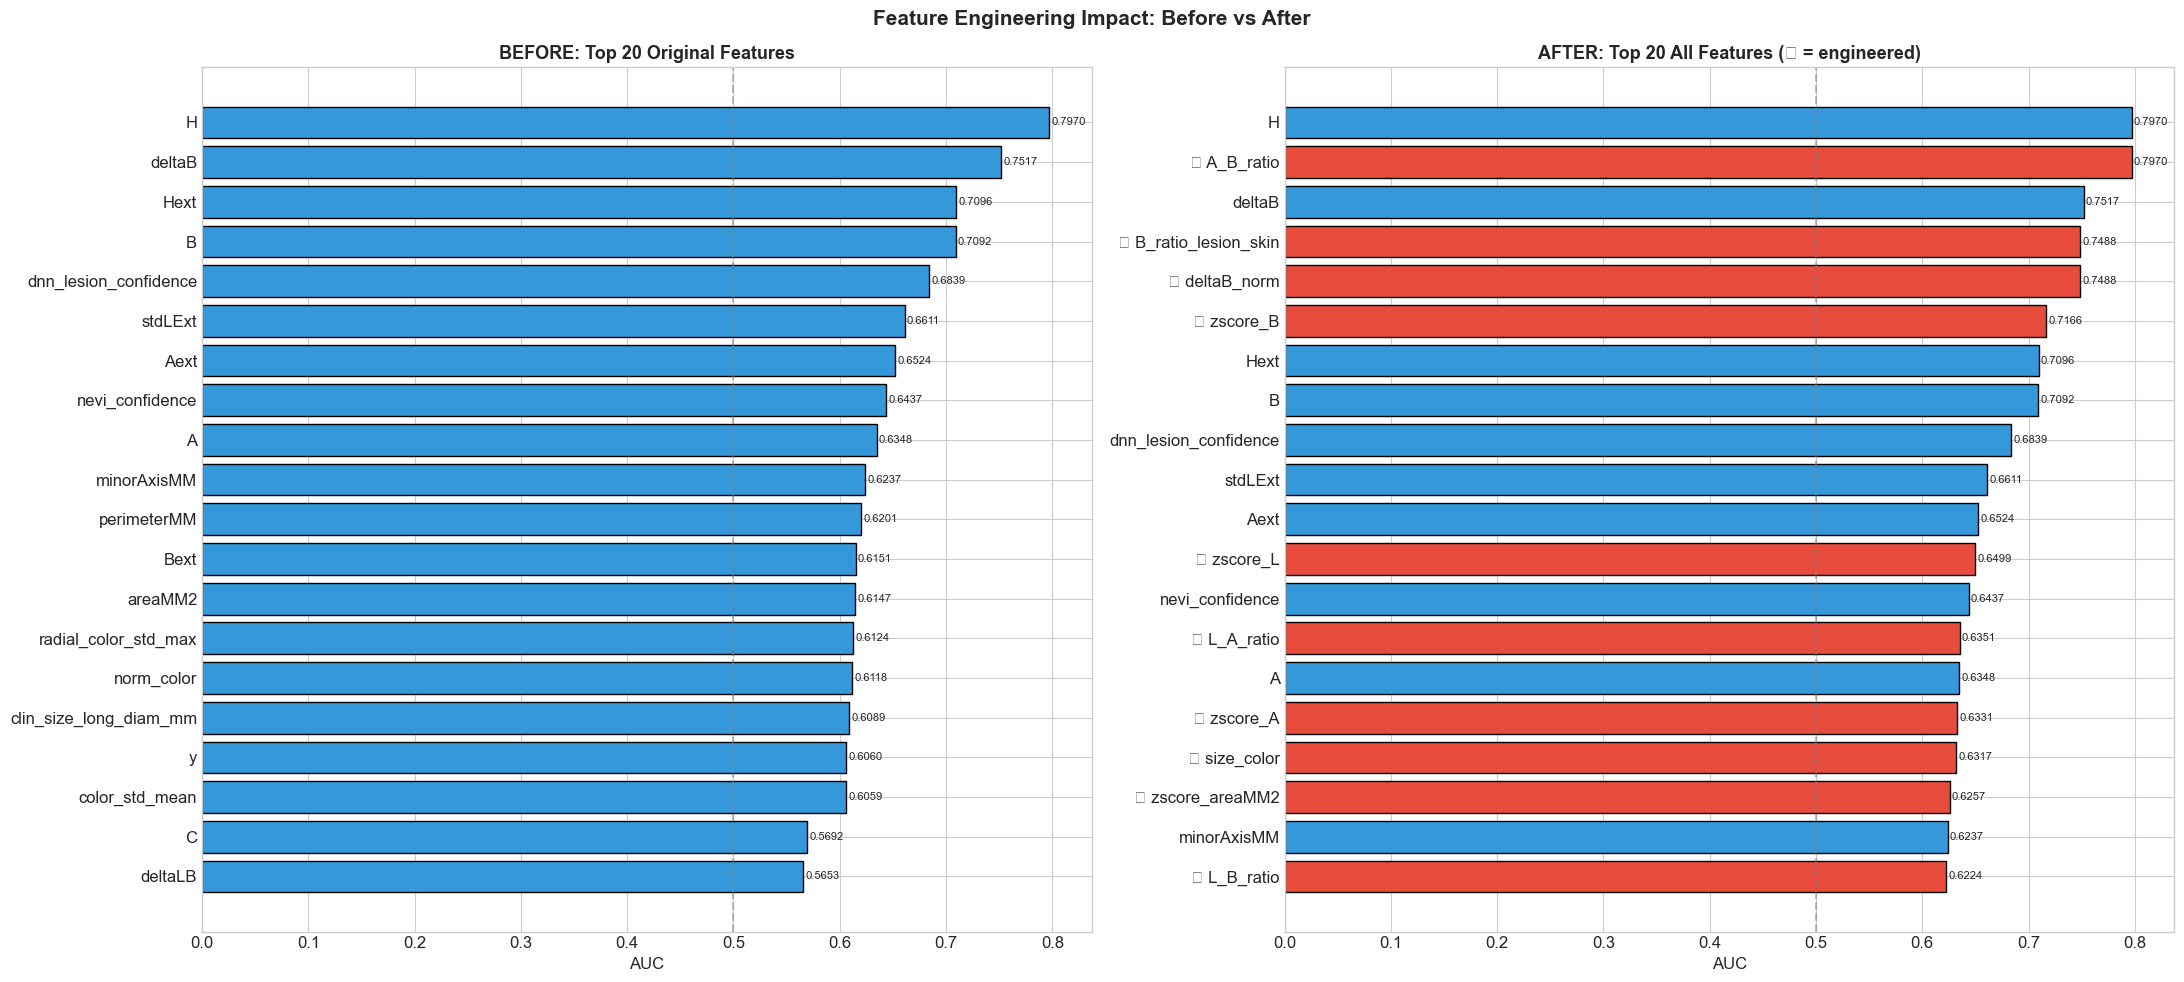


📌 IMPACT ASSESSMENT:
   Engineered features in top-20: 10 / 20
   Total original features: 35
   Total features after engineering: 78
   Best original AUC: 0.7970
   Best overall AUC: 0.7970


In [4]:
# ============================================================
# 3.3 — Visualization: Top Features Before vs After
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# Original top 20
top_orig = original_aucs.head(20)
axes[0].barh(range(len(top_orig)), top_orig.values, color='#3498db', edgecolor='black')
axes[0].set_yticks(range(len(top_orig)))
axes[0].set_yticklabels([f.replace('tbp_lv_', '') for f in top_orig.index])
axes[0].set_xlabel('AUC')
axes[0].set_title('BEFORE: Top 20 Original Features', fontweight='bold', fontsize=13)
axes[0].invert_yaxis()
axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
for i, v in enumerate(top_orig.values):
    axes[0].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=8)

# All features top 20 (mixed original + engineered)
top_all = all_aucs.head(20)
bar_colors = ['#e74c3c' if f.startswith('feat_') or f.endswith('_encoded') else '#3498db' 
              for f in top_all.index]
axes[1].barh(range(len(top_all)), top_all.values, color=bar_colors, edgecolor='black')
axes[1].set_yticks(range(len(top_all)))
axes[1].set_yticklabels([f.replace('tbp_lv_', '').replace('feat_', '⭐ ') for f in top_all.index])
axes[1].set_xlabel('AUC')
axes[1].set_title('AFTER: Top 20 All Features (⭐ = engineered)', fontweight='bold', fontsize=13)
axes[1].invert_yaxis()
axes[1].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
for i, v in enumerate(top_all.values):
    axes[1].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=8)

plt.suptitle('Feature Engineering Impact: Before vs After', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '10_feature_engineering_impact.png'), dpi=150, bbox_inches='tight')
plt.show()

n_new_in_top20 = sum(1 for f in top_all.index[:20] if f.startswith('feat_') or f.endswith('_encoded'))
print(f"\n📌 IMPACT ASSESSMENT:")
print(f"   Engineered features in top-20: {n_new_in_top20} / 20")
print(f"   Total original features: {len(original_aucs)}")
print(f"   Total features after engineering: {len(all_aucs)}")
print(f"   Best original AUC: {original_aucs.max():.4f}")
print(f"   Best overall AUC: {all_aucs.max():.4f}")

## 3.3 Feature Selection via Mutual Information

Mutual information captures non-linear dependencies and helps us identify truly informative 
features beyond what Pearson correlation reveals.

> **Leakage control:** AUC/MI rankings use rows from **one StratifiedGroupKFold training fold** (~80% of patients), not the full dataset.


Computing mutual information on 50,000 rows (from selection train), 79 features...


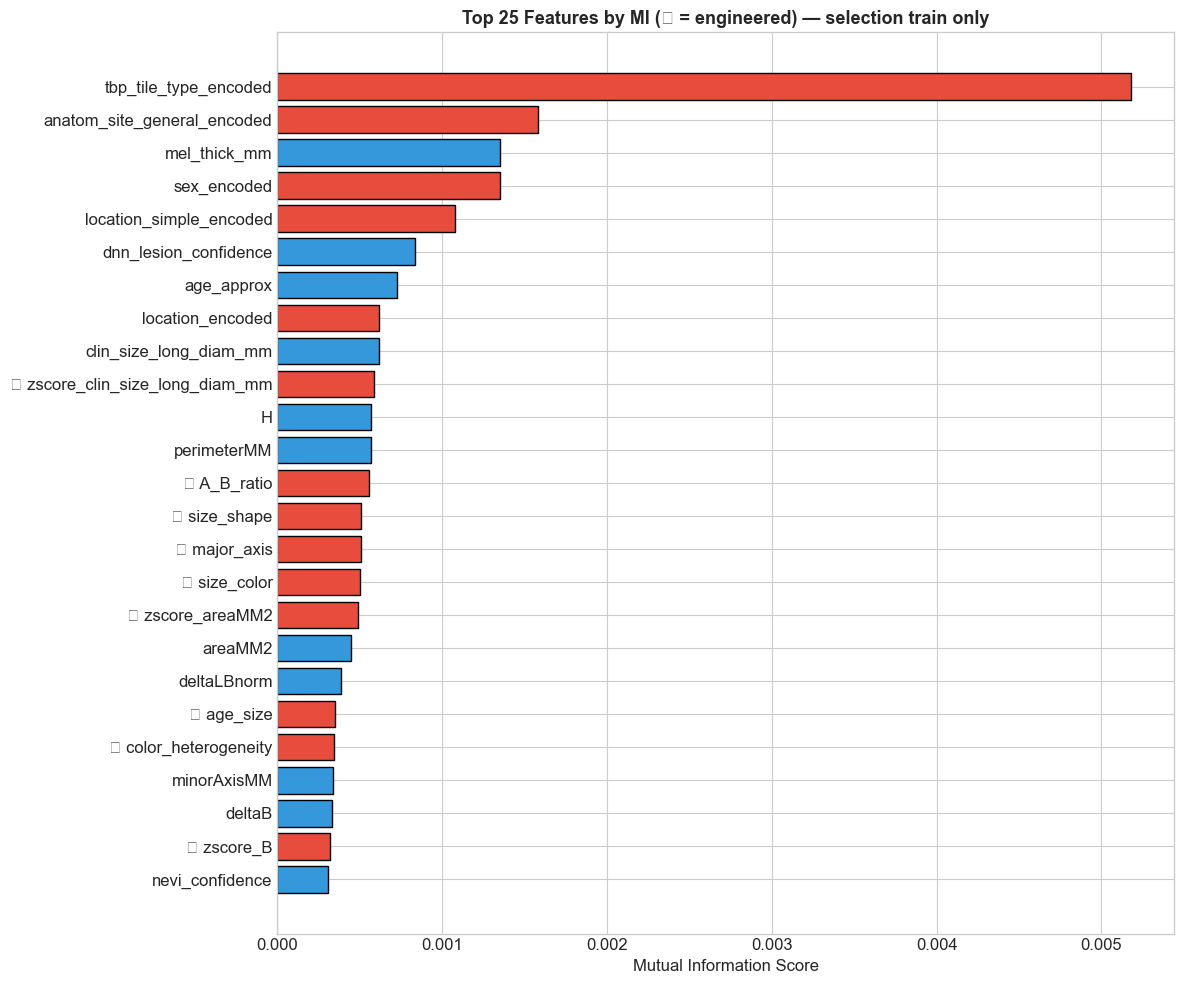


📌 AUC/MI rankings use one StratifiedGroupKFold train fold (no val patients) to reduce selection leakage.


In [5]:
# ============================================================
# 3.4 — Mutual Information Analysis (selection train, sampled)
# ============================================================
from sklearn.feature_selection import mutual_info_classif

sample_size = min(50000, len(SELECTION_TRAIN_IDX))
rng = np.random.default_rng(SEED)
sel_sub = rng.choice(SELECTION_TRAIN_IDX, size=sample_size, replace=False)
df_sample = df_feat.iloc[sel_sub]

feat_cols = [c for c in df_feat.select_dtypes(include=[np.number]).columns if c != 'target']
X_sample = df_sample[feat_cols].fillna(0)
y_sample = df_sample['target']

print(f"Computing mutual information on {sample_size:,} rows (from selection train), {len(feat_cols)} features...")
mi_scores = mutual_info_classif(X_sample, y_sample, random_state=SEED, n_neighbors=5)
mi_df = pd.DataFrame({'Feature': feat_cols, 'MI': mi_scores}).sort_values('MI', ascending=False)

fig, ax = plt.subplots(figsize=(12, 10))
top_mi = mi_df.head(25)
bar_colors = ['#e74c3c' if f.startswith('feat_') or f.endswith('_encoded') else '#3498db'
              for f in top_mi['Feature']]
ax.barh(range(len(top_mi)), top_mi['MI'].values, color=bar_colors, edgecolor='black')
ax.set_yticks(range(len(top_mi)))
ax.set_yticklabels([f.replace('tbp_lv_', '').replace('feat_', '⭐ ') for f in top_mi['Feature']])
ax.set_xlabel('Mutual Information Score')
ax.set_title('Top 25 Features by MI (⭐ = engineered) — selection train only', fontweight='bold', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '11_mutual_information.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 AUC/MI rankings use one StratifiedGroupKFold train fold (no val patients) to reduce selection leakage.")


## 3.4 Final Feature Set Selection

In [6]:
# ============================================================
# 3.5 — Define Final Feature Set
# ============================================================
SITE_RESIDUAL_COLS = [
    'feat_areaMM2_vs_site',
    'feat_color_std_mean_vs_site',
    'feat_eccentricity_vs_site',
]
SITE_RAW_COLS = ['tbp_lv_areaMM2', 'tbp_lv_color_std_mean', 'tbp_lv_eccentricity']

auc_top50 = set(all_aucs.head(50).index)
mi_top50 = set(mi_df.head(50)['Feature'].values)
robust_features = sorted(auc_top50 | mi_top50)

exclude = {'target', 'isic_id', 'patient_id', 'lesion_id', 'attribution',
           'copyright_license', 'iddx_full', 'iddx_1', 'iddx_2', 'iddx_3',
           'iddx_4', 'iddx_5', 'mel_mitotic_index', 'mel_thick_mm'}
robust_features = [f for f in robust_features if f not in exclude and f in df_feat.columns]
# Site residuals are added in Notebook 4 per fold — never in df_feat here
robust_features = [f for f in robust_features if f not in SITE_RESIDUAL_COLS]

print(f"Final tabular feature set: {len(robust_features)} columns")
print(f"  Union of top-50 AUC + top-50 MI on selection train: {len(auc_top50 | mi_top50)} before exclusions")
print(f"  Site residual features ({len(SITE_RESIDUAL_COLS)}) are appended during CV in Notebook 4")

for i, f in enumerate(robust_features):
    tag = "NEW" if f.startswith('feat_') or f.endswith('_encoded') else "ORIG"
    print(f"  [{tag}] {f}")

df_feat.to_pickle(os.path.join(ROOT, 'outputs', 'train_featured.pkl'))
pd.Series(robust_features).to_csv(os.path.join(ROOT, 'outputs', 'feature_list.csv'), index=False)
print(f"\n✅ Saved train_featured.pkl and feature_list.csv ({len(robust_features)} tabular features)")


Final tabular feature set: 64 columns
  Union of top-50 AUC + top-50 MI on selection train: 65 before exclusions
  Site residual features (3) are appended during CV in Notebook 4
  [ORIG] age_approx
  [NEW] anatom_site_general_encoded
  [ORIG] clin_size_long_diam_mm
  [NEW] feat_A_B_ratio
  [NEW] feat_A_ratio_lesion_skin
  [NEW] feat_B_ratio_lesion_skin
  [NEW] feat_L_A_ratio
  [NEW] feat_L_B_ratio
  [NEW] feat_L_ratio_lesion_skin
  [NEW] feat_age_size
  [NEW] feat_asymm_color
  [NEW] feat_axis_ratio
  [NEW] feat_border_delta
  [NEW] feat_border_irregularity
  [NEW] feat_chroma
  [NEW] feat_color_heterogeneity
  [NEW] feat_deltaA_norm
  [NEW] feat_deltaB_norm
  [NEW] feat_deltaE
  [NEW] feat_deltaL_norm
  [NEW] feat_delta_magnitude
  [NEW] feat_log_deltaLB
  [NEW] feat_log_patient_lesions
  [NEW] feat_major_axis
  [NEW] feat_patient_lesion_count
  [NEW] feat_size_color
  [NEW] feat_size_shape
  [NEW] feat_zscore_A
  [NEW] feat_zscore_B
  [NEW] feat_zscore_L
  [NEW] feat_zscore_areaMM2


## 3.5 Preprocessing: Encoding & Scaling

Notebook 3 saves **unimputed** numeric features (NaN/inf → NaN). **Median imputation** is applied in Notebook 4 **per cross-validation fold**, fit on training rows only.


In [7]:
# ============================================================
# 3.6 — Preprocessing Pipeline
# ============================================================
from sklearn.preprocessing import LabelEncoder

SITE_RESIDUAL_COLS = [
    'feat_areaMM2_vs_site',
    'feat_color_std_mean_vs_site',
    'feat_eccentricity_vs_site',
]
SITE_RAW_COLS = ['tbp_lv_areaMM2', 'tbp_lv_color_std_mean', 'tbp_lv_eccentricity']

cat_cols_to_encode = ['sex', 'anatom_site_general', 'tbp_tile_type',
                      'tbp_lv_location', 'tbp_lv_location_simple', 'image_type']
label_encoders = {}
for col in cat_cols_to_encode:
    if col in df_feat.columns:
        le = LabelEncoder()
        df_feat[col + '_le'] = le.fit_transform(df_feat[col].astype(str))
        label_encoders[col] = le

feature_cols = [c for c in robust_features if c in df_feat.columns]
for col in cat_cols_to_encode:
    le_col = col + '_le'
    if le_col in df_feat.columns and le_col not in feature_cols:
        feature_cols.append(le_col)

X = df_feat[feature_cols].copy()
y = df_feat['target'].values
groups = df_feat['patient_id'].values
X = X.replace([np.inf, -np.inf], np.nan)

n_nan = int(X.isna().sum().sum())
print(f"✅ Feature matrix (unimputed for CV): {X.shape}")
print(f"   Missing cells: {n_nan:,} (median imputation runs per fold in Notebook 4)")
print(f"   Target: {len(y)} samples, {y.sum()} positive")
print(f"   Groups (patients): {len(np.unique(groups)):,} unique")
print(f"   Tabular features in pickle: {len(feature_cols)}")

import pickle
prep_data = {
    'X': X,
    'y': y,
    'groups': groups,
    'feature_cols': feature_cols,
    'site_residual_cols': SITE_RESIDUAL_COLS,
    'site_raw_cols': SITE_RAW_COLS,
    'label_encoders': label_encoders,
    'imputer_per_fold': True,
    'df_feat': df_feat,
}
with open(os.path.join(ROOT, 'outputs', 'preprocessed_data.pkl'), 'wb') as f:
    pickle.dump(prep_data, f)
print(f"\n✅ Saved preprocessed_data.pkl")


✅ Feature matrix (unimputed for CV): (401059, 70)
   Missing cells: 5,636 (median imputation runs per fold in Notebook 4)
   Target: 401059 samples, 393 positive
   Groups (patients): 1,042 unique
   Tabular features in pickle: 70

✅ Saved preprocessed_data.pkl


---
**Next Notebook:** `04_Model_Training.ipynb` — Phase 1: train LightGBM and XGBoost with patient-grouped CV and tabular ensemble (Phase 2 adds images + fusion).